# Import Libraries

In [52]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/yashbhardwaj/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yashbhardwaj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load Dataset

In [15]:
df = pd.read_csv("customer_support_text_classification.csv")

print(df.head())

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  


# Task 1: Dataset Understanding
## Number of Records

In [16]:
print("Number of Records:", len(df))

Number of Records: 1500


## Target Labels

In [17]:
print(df['sentiment_label'].unique())

['neutral' 'positive' 'negative']


# Sample Text Records

In [18]:
print(df['customer_message'].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


# Average Text Length

In [19]:
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))

print("Average Text Length:", df['text_length'].mean())

Average Text Length: 12.722666666666667


# Class Distribution

In [20]:
print(df['sentiment_label'].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


# Visualization

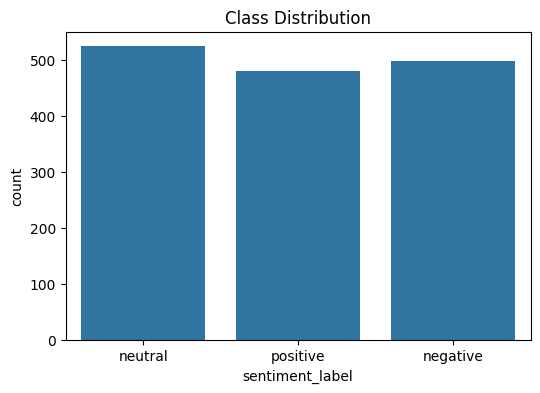

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment_label', data=df)
plt.title("Class Distribution")
plt.savefig("results/model_evaluation.png")
plt.show()

# Theory for Task 1

 ## Explanation

   This dataset is used for sentiment classification of customer support messages.

The target column is:

  . sentiment_label

   Possible classes are:

   . Positive

   . Neutral

   . Negative

  The input feature is:

  . customer_message
  
  The dataset contains customer queries and complaints from support systems.

# Task 2: Text Preprocessing
  ## Stopwords

In [22]:
stop_words = set(stopwords.words('english'))

# Cleaning Function

In [24]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

# Apply Cleaning

In [25]:
df['cleaned_text'] = df['customer_message'].apply(clean_text)

print(df[['customer_message', 'cleaned_text']].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                        cleaned_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


# Theory for Preprocessing

## Why Preprocessing is Important
   Text data contains:

. Symbols

. Uppercase/lowercase inconsistency

 . Unnecessary words

 . Noise
 
Preprocessing improves model performance by converting text into clean and meaningful tokens.

# Task 3: Text Vectorization

  ## TF-IDF Vectorization

In [26]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text']).toarray()

y = df['sentiment_label']

# Theory

  ## Why Text Must Be Converted into Numerical Vectors

Machine learning models cannot understand raw text directly.

Text must be converted into numbers because models perform mathematical operations on numerical data.

TF-IDF helps by:

 . Giving importance to meaningful words

 . Reducing importance of common words

 . Creating numerical representation of text


# Task 4: Baseline Model
  ## Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model

In [31]:
model = LogisticRegression()

model.fit(X_train, y_train)

/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sk

LogisticRegression()

# Predictions

In [39]:
y_pred = model.predict(X_test)

/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yashbhardwaj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# Evaluation


In [40]:
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score:
1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



# Confusion Matrix

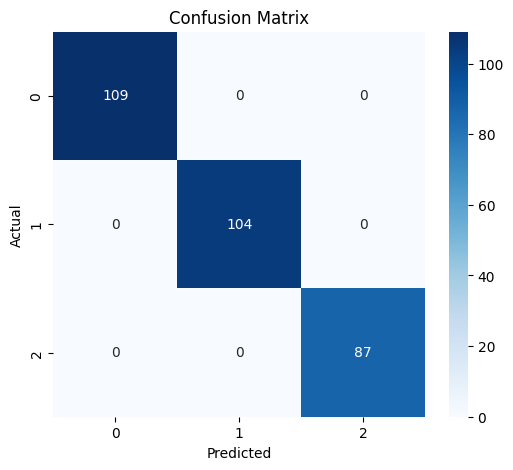

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Save Sample Predictions

In [42]:
sample_output = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

sample_output.head(20).to_csv(
    "results/sample_predictions.txt",
    index=False
)

# Task 5: Sequence Model (LSTM)

  ## Tokenization

In [43]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# Padding

In [44]:
max_length = 50

X_seq = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

# Label Encoding

In [45]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# Train-Test Split

In [46]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# Build LSTM Model

In [48]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=5000, output_dim=128, input_length=max_length)
)

lstm_model.add(LSTM(64))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(32, activation='relu'))

lstm_model.add(Dense(3, activation='softmax'))

# Compile Model

In [49]:
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train Model

In [50]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3327 - loss: 1.0997 - val_accuracy: 0.3292 - val_loss: 1.0991
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3457 - loss: 1.0997 - val_accuracy: 0.3292 - val_loss: 1.0994
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3287 - loss: 1.0992 - val_accuracy: 0.3292 - val_loss: 1.0990
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3386 - loss: 1.0987 - val_accuracy: 0.3292 - val_loss: 1.1003
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3476 - loss: 1.0982 - val_accuracy: 0.3292 - val_loss: 1.1007


# Evaluate

In [51]:
loss, accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)

print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3477 - loss: 1.0984
Test Accuracy: 0.3466666638851166


# Theory for LSTM Architecture

 ## Architecture Explanation
1. Input Sequence
The customer message is converted into sequences of tokens.

Example:

"I need refund immediately"

becomes:

[45, 102, 87, 210]

2. Embedding Layer

The embedding layer converts token IDs into dense vectors.

Purpose:

 . Captures semantic meaning

 . Learns relationships between words


3. LSTM Layer

The LSTM processes words sequentially and remembers important context.

It helps understand sentence meaning over time.

4. Output Layer

Softmax activation predicts:

 . Positive

 . Neutral

 . Negative

5. Loss Function

Sparse Categorical Crossentropy

Used for multiclass classification.

6. Evaluation Metric

Accuracy

Measures correct predictions percentage.

# Task 6: Attention and Transformer Reflection

 ## Why RNNs Struggle with Long-Term Dependencies

Standard RNNs forget older information while processing long sequences.

This happens because of:

 . Vanishing gradients

 . Difficulty retaining memory for long text

How LSTMs Help

LSTMs introduce:

 . Memory cell

 . Forget gate

 . Input gate

 . Output gate

These components help preserve important information for longer durations.

### What Attention Solves

Attention allows the model to focus on important words in the sequence.

Instead of relying only on the final hidden state, attention checks all relevant words during prediction.

Example:

In translation tasks, attention helps identify which source words are most important.

 ### Why Transformers are Important

Transformers:

 . Process text in parallel

 . Use self-attention mechanisms

 . Handle long dependencies efficiently

 . Train faster than RNNs

Modern Generative AI systems like:

 . OpenAI GPT

 . Google BERT

 . Meta LLaMA

are based on transformer architectures.

Transformers are now the foundation of modern NLP and Generative AI systems.